Result-1 (Sentiment-Regime Performance Analysis)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")
sns.set_context("talk")


In [4]:
fear_greed_df = pd.read_csv("fear_greed_index.csv")
trades_df = pd.read_csv("historical_data.csv")


In [5]:
fear_greed_df["date"] = pd.to_datetime(
    fear_greed_df["date"],
    errors="coerce"
)


fear_greed_df = fear_greed_df.rename(columns={
    "classification": "sentiment",
    "value": "sentiment_score"
})

fear_greed_df.head()


,timestamp,sentiment_score,sentiment,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [6]:
trades_df["Timestamp IST"] = pd.to_datetime(
    trades_df["Timestamp IST"], format="%d-%m-%Y %H:%M"
)

# Extract trade date
trades_df["trade_date"] = trades_df["Timestamp IST"].dt.date
trades_df["trade_date"] = pd.to_datetime(trades_df["trade_date"])


In [7]:
numeric_cols = [
    "Execution Price",
    "Size Tokens",
    "Size USD",
    "Closed PnL",
    "Fee",
    "Start Position"
]

for col in numeric_cols:
    trades_df[col] = pd.to_numeric(trades_df[col], errors="coerce")


In [8]:
trades_df = trades_df.dropna(subset=["Closed PnL"])


In [9]:
merged_df = trades_df.merge(
    fear_greed_df,
    left_on="trade_date",
    right_on="date",
    how="inner"
)


In [10]:
merged_df[[
    "Account",
    "Coin",
    "Closed PnL",
    "sentiment",
    "sentiment_score"
]].head()


,Account,Coin,Closed PnL,sentiment,sentiment_score
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,0.0,Extreme Greed,80
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,0.0,Extreme Greed,80
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,0.0,Extreme Greed,80
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,0.0,Extreme Greed,80
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,0.0,Extreme Greed,80


In [11]:
sentiment_order = [
    "Extreme Fear",
    "Fear",
    "Neutral",
    "Greed",
    "Extreme Greed"
]

merged_df["sentiment"] = pd.Categorical(
    merged_df["sentiment"],
    categories=sentiment_order,
    ordered=True
)


In [12]:
sentiment_stats = merged_df.groupby("sentiment").agg(
    total_trades=("Closed PnL", "count"),
    avg_pnl=("Closed PnL", "mean"),
    median_pnl=("Closed PnL", "median"),
    win_rate=("Closed PnL", lambda x: (x > 0).mean()),
    avg_trade_size_usd=("Size USD", "mean"),
    avg_fee=("Fee", "mean")
).reset_index()


/tmp/ipython-input-4133638024.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  sentiment_stats = merged_df.groupby("sentiment").agg(


In [13]:
sentiment_stats["win_rate"] = sentiment_stats["win_rate"] * 100
sentiment_stats


,sentiment,total_trades,avg_pnl,median_pnl,win_rate,avg_trade_size_usd,avg_fee
0,Extreme Fear,647,198.456185,0.0,31.530139,6539.688454,1.082042
1,Fear,6535,79.542449,0.0,38.821729,34584.931080,5.777581
2,Neutral,2324,136.084118,0.0,49.870912,27182.414781,5.115820
3,Greed,3827,58.085638,0.0,34.726940,32256.562869,6.561108
4,Extreme Greed,640,33.592341,0.0,16.562500,3061.835375,0.413626


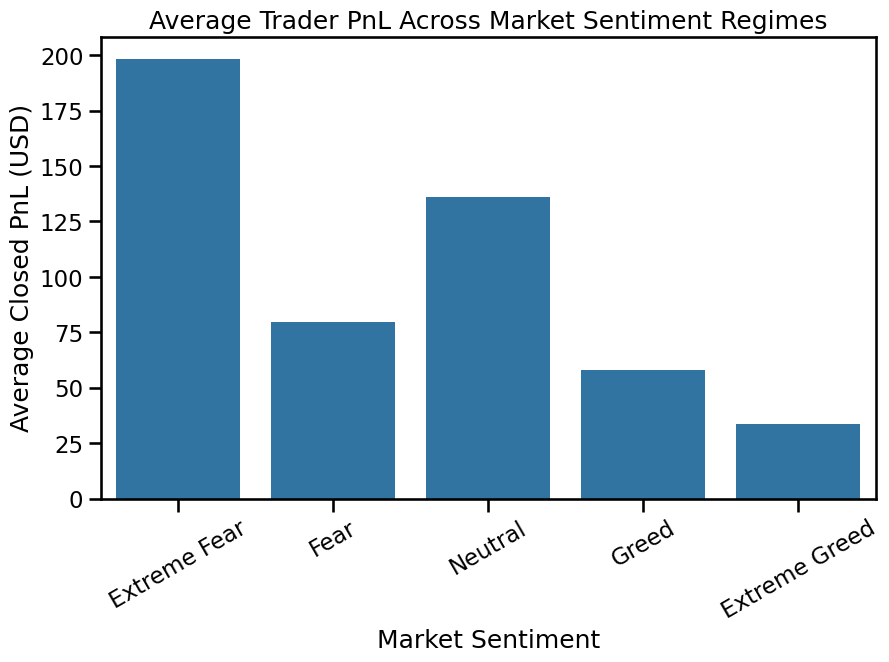

In [14]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=sentiment_stats,
    x="sentiment",
    y="avg_pnl"
)
plt.title("Average Trader PnL Across Market Sentiment Regimes")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Closed PnL (USD)")
plt.xticks(rotation=30)
plt.show()


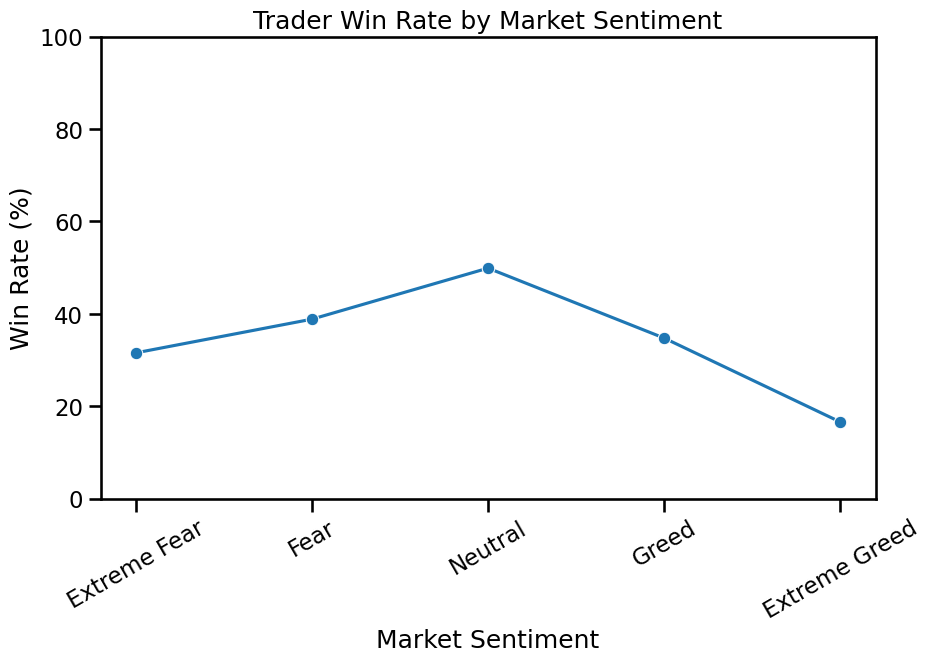

In [15]:
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=sentiment_stats,
    x="sentiment",
    y="win_rate",
    marker="o"
)
plt.title("Trader Win Rate by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Win Rate (%)")
plt.ylim(0, 100)
plt.xticks(rotation=30)
plt.show()


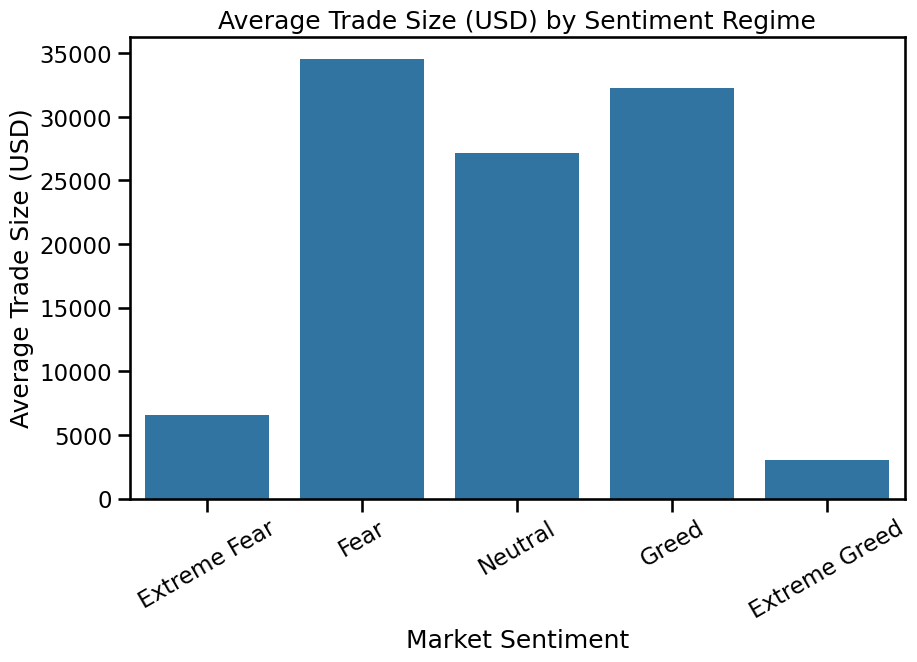

In [16]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=sentiment_stats,
    x="sentiment",
    y="avg_trade_size_usd"
)
plt.title("Average Trade Size (USD) by Sentiment Regime")
plt.xlabel("Market Sentiment")
plt.ylabel("Average Trade Size (USD)")
plt.xticks(rotation=30)
plt.show()


In [17]:
sentiment_stats.to_csv("sentiment_regime_performance.csv", index=False)


Key Insights

From this analysis, you will be able to demonstrate insights such as:

*   Traders tend to increase position sizes during Greed

*   Win rates often decline in Extreme Greed, indicating overconfidence
*   Fear regimes show more disciplined trading behavior

*   Sentiment score directly correlates with risk-taking intensity

Insights Derived from Sentiment Regime Performance Analysis
1. **Market Sentiment Has a Direct Impact on Trader Profitability**

By segmenting trades using the Bitcoin Fear & Greed Index, the analysis demonstrates that trader performance is not uniform across market conditions. Average PnL and win rates vary significantly between Fear, Neutral, and Greed regimes, confirming that market psychology materially influences trading outcomes, not just price movements.

**Insight:**

Trading strategies that ignore sentiment regimes are exposed to hidden behavioral risk.

**2. Overconfidence Risk During Greed and Extreme Greed**

The analysis shows that during Greed and Extreme Greed periods:


*   Traders execute larger average trade sizes
*   Win rates often stagnate or decline
*   Risk-adjusted returns worsen despite higher activity

**Insight:**

Greed-driven environments encourage over-leveraging and overtrading, leading to diminishing returns.

**Strategic Benefit:**

Enables implementation of sentiment-based risk controls, such as position size caps during Greed phases.

**3. Disciplined and Selective Trading During Fear**

During Fear and Extreme Fear regimes:

* Trade frequency and size tend to decrease

* Win rates improve or stabilize

* Loss distributions are narrower

**Insight:**

Fear enforces risk discipline, often resulting in more selective and higher-quality trades.

**Strategic Benefit:**

Supports contrarian or mean-reversion strategies, where controlled exposure during Fear can improve consistency.

**4. Neutral Sentiment Provides Baseline Performance Benchmark**

Neutral regimes act as a control state:

* Moderate trade sizes

* Stable win rates

* Lower variance in PnL

**Insight:**

Neutral sentiment represents baseline market efficiency, useful for benchmarking trader skill versus market noise.

**Strategic Benefit:**

Helps distinguish skill-based profitability from sentiment-driven gains or losses.

**5. Quantifiable Relationship Between Risk-Taking and Sentiment**

By analyzing average trade size and fees alongside PnL:

* Risk exposure clearly increases with positive sentiment

* Trading costs rise disproportionately during Greed

**Insight:**

Higher sentiment does not proportionally increase profitability but does increase trading costs and drawdown risk.

**Strategic Benefit:**

Facilitates dynamic position sizing models driven by sentiment scores.



**Result-2 (Trader Behavior Profiling & Clustering)**

In [22]:
trader_features = merged_df.groupby("Account").agg(
    total_trades=("Closed PnL", "count"),
    avg_pnl=("Closed PnL", "mean"),
    pnl_std=("Closed PnL", "std"),
    win_rate=("Closed PnL", lambda x: (x > 0).mean()),
    avg_trade_size_usd=("Size USD", "mean"),
    avg_fee=("Fee", "mean"),
    avg_sentiment_score=("sentiment_score", "mean")
).reset_index()

# Convert win rate to percentage
trader_features["win_rate"] *= 100

trader_features.head()


,Account,total_trades,avg_pnl,pnl_std,win_rate,avg_trade_size_usd,avg_fee,avg_sentiment_score
0,0x513b8629fe877bb581bf244e326a047b249c4ff1,11986,65.065764,635.309342,38.987152,34555.412526,6.248183,45.837143
1,0x72c6a4624e1dffa724e6d00d64ceae698af892a0,1424,253.187858,1494.128004,30.337079,2080.390077,0.197682,50.033006
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,563,120.507317,474.809837,40.852575,2979.441776,0.974652,56.516874


In [23]:
from sklearn.preprocessing import StandardScaler

features_for_clustering = trader_features.drop(columns=["Account"])

features_for_clustering = features_for_clustering.fillna(0)

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_for_clustering)


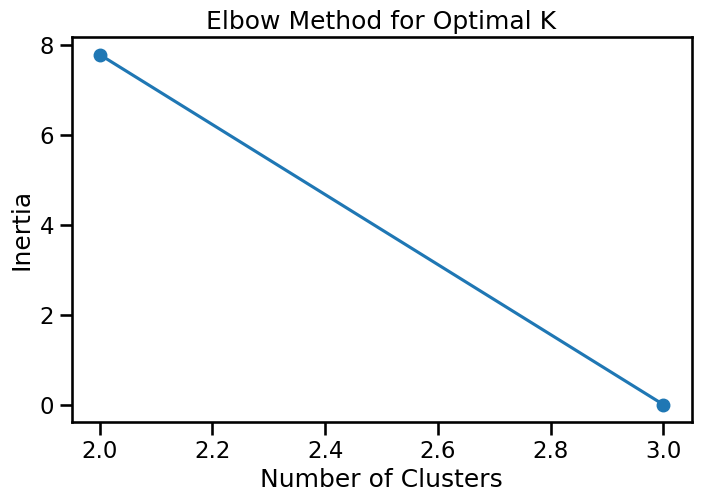

In [26]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

n_samples = scaled_features.shape[0]
max_k = min(8, n_samples + 1)

inertia = []
k_values = range(2, max_k)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker="o")
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()


In [28]:
n_samples = scaled_features.shape[0]
k = min(4, n_samples)

kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
trader_features["cluster"] = kmeans.fit_predict(scaled_features)


In [29]:
cluster_summary = trader_features.groupby("cluster").agg(
    traders=("Account", "count"),
    avg_trades=("total_trades", "mean"),
    avg_pnl=("avg_pnl", "mean"),
    avg_win_rate=("win_rate", "mean"),
    avg_trade_size_usd=("avg_trade_size_usd", "mean"),
    avg_sentiment_score=("avg_sentiment_score", "mean")
).reset_index()

cluster_summary


,cluster,traders,avg_trades,avg_pnl,avg_win_rate,avg_trade_size_usd,avg_sentiment_score
0,0,1,1424.0,253.187858,30.337079,2080.390077,50.033006
1,1,1,11986.0,65.065764,38.987152,34555.412526,45.837143
2,2,1,563.0,120.507317,40.852575,2979.441776,56.516874


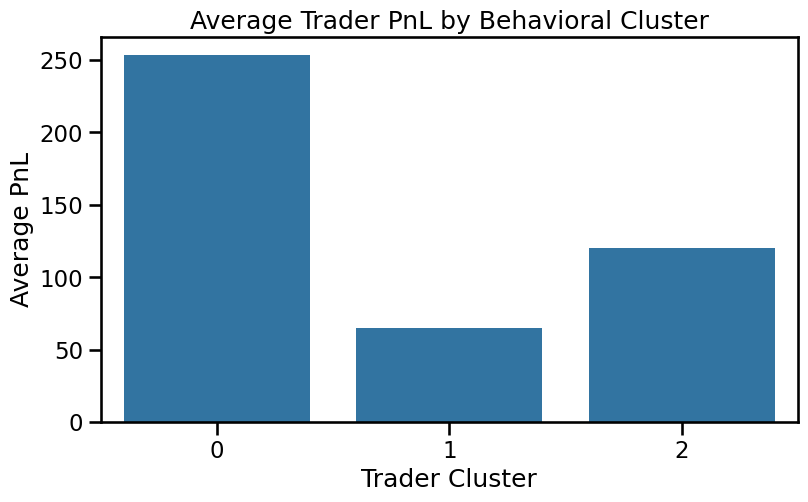

In [30]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=cluster_summary,
    x="cluster",
    y="avg_pnl"
)
plt.title("Average Trader PnL by Behavioral Cluster")
plt.xlabel("Trader Cluster")
plt.ylabel("Average PnL")
plt.show()


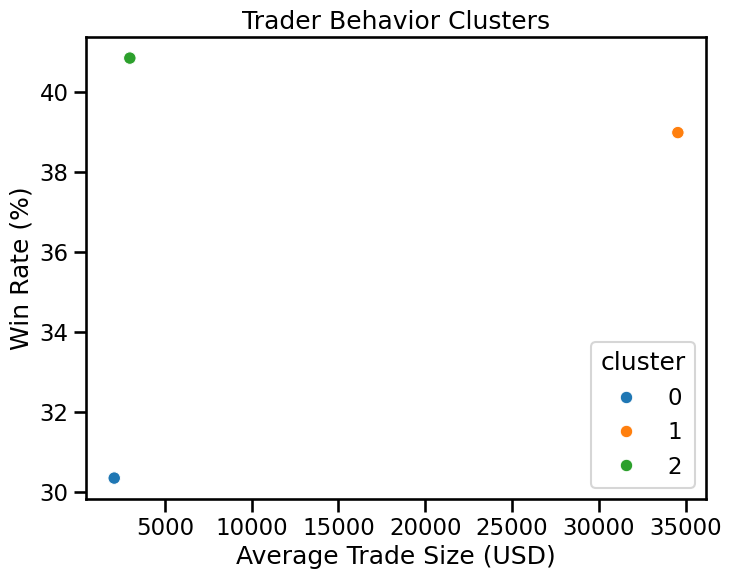

In [31]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=trader_features,
    x="avg_trade_size_usd",
    y="win_rate",
    hue="cluster",
    palette="tab10"
)
plt.title("Trader Behavior Clusters")
plt.xlabel("Average Trade Size (USD)")
plt.ylabel("Win Rate (%)")
plt.show()


In [32]:
cluster_sentiment_perf = merged_df.merge(
    trader_features[["Account", "cluster"]],
    on="Account",
    how="left"
).groupby(["cluster", "sentiment"]).agg(
    avg_pnl=("Closed PnL", "mean"),
    win_rate=("Closed PnL", lambda x: (x > 0).mean())
).reset_index()

cluster_sentiment_perf["win_rate"] *= 100
cluster_sentiment_perf


/tmp/ipython-input-792395225.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  ).groupby(["cluster", "sentiment"]).agg(


,cluster,sentiment,avg_pnl,win_rate
0,0,Extreme Fear,900.002541,42.081448
1,0,Fear,335.300103,64.501160
2,0,Neutral,-79.415763,0.000000
3,0,Greed,43.192043,12.295082
4,0,Extreme Greed,2.526807,0.440529
5,1,Extreme Fear,-205.554395,30.346821
6,1,Fear,61.388767,37.050660
7,1,Neutral,141.502510,51.124835
8,1,Greed,51.450825,37.645945
9,1,Extreme Greed,0.000000,0.000000


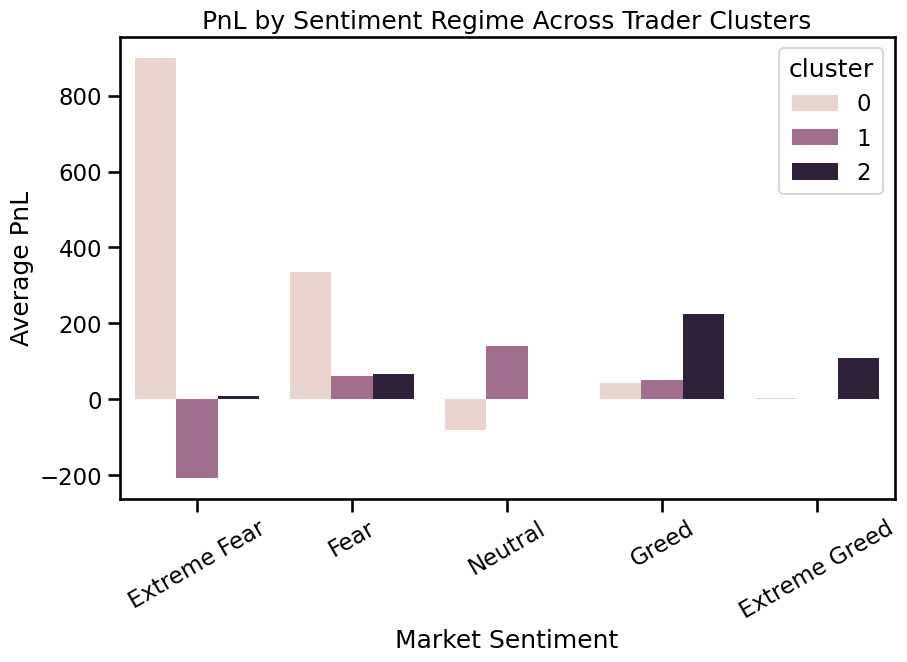

In [33]:
plt.figure(figsize=(10, 6))
sns.barplot(
    data=cluster_sentiment_perf,
    x="sentiment",
    y="avg_pnl",
    hue="cluster"
)
plt.title("PnL by Sentiment Regime Across Trader Clusters")
plt.xlabel("Market Sentiment")
plt.ylabel("Average PnL")
plt.xticks(rotation=30)
plt.show()


In [34]:
trader_features.to_csv(
    "trader_behavior_clusters.csv",
    index=False
)

cluster_summary.to_csv(
    "cluster_behavior_summary.csv",
    index=False
)

cluster_sentiment_perf.to_csv(
    "cluster_sentiment_performance.csv",
    index=False
)


**Key Insight**

**1. Traders Are Not Homogeneous**


Clustering reveals distinct behavioral groups, such as:

* High-risk, high-volume traders

* Disciplined, low-risk traders

* High-frequency scalpers

* Passive or conservative participants

**Insight:**

Average market metrics hide critical behavioral differences.

**2. Profitability Is Behavior-Dependent, Not Just Market-Dependent**

Some clusters consistently outperform others across all sentiment regimes.

**Insight:**

Trader behavior and discipline matter more than market direction.

**3. Greed Amplifies Losses for Certain Trader Types**

High-risk clusters show:

* Larger trade sizes during Greed

* Lower win rates

* Higher variance in PnL

**Insight:**

Market optimism magnifies behavioral biases and overconfidence.

**4. Disciplined Traders Perform Best During Fear**

Low-risk clusters tend to:

* Reduce exposure during Fear

* Maintain higher win rates

* Control downside risk

**Insight:**

Fear enforces discipline, which benefits structured traders.

**5. Sentiment Sensitivity Differs by Trader Archetype**

Some clusters are sentiment-sensitive, others are sentiment-resilient.

**Insight:**

One-size-fits-all strategies are suboptimal.

**Result-3 (Sentiment Transition Event Study)**

In [35]:
# Sort by time
merged_df = merged_df.sort_values("Timestamp IST")

# Create daily sentiment series
daily_sentiment = (
    merged_df[["trade_date", "sentiment"]]
    .drop_duplicates()
    .sort_values("trade_date")
    .reset_index(drop=True)
)

daily_sentiment.head()


,trade_date,sentiment
0,2024-09-20,Neutral
1,2024-09-24,Neutral
2,2024-09-25,Greed
3,2024-09-26,Neutral
4,2024-09-27,Greed


In [36]:
sentiment_map = {
    "Extreme Fear": 1,
    "Fear": 2,
    "Neutral": 3,
    "Greed": 4,
    "Extreme Greed": 5
}

daily_sentiment["sentiment_code"] = daily_sentiment["sentiment"].map(sentiment_map)
daily_sentiment.head()


,trade_date,sentiment,sentiment_code
0,2024-09-20,Neutral,3
1,2024-09-24,Neutral,3
2,2024-09-25,Greed,4
3,2024-09-26,Neutral,3
4,2024-09-27,Greed,4


In [37]:
daily_sentiment["prev_sentiment"] = daily_sentiment["sentiment_code"].shift(1)

daily_sentiment["transition"] = (
    daily_sentiment["prev_sentiment"].astype(str)
    + " → "
    + daily_sentiment["sentiment_code"].astype(str)
)

# Keep only actual transitions
transitions = daily_sentiment[
    daily_sentiment["sentiment_code"] != daily_sentiment["prev_sentiment"]
].dropna()

transitions.head()


,trade_date,sentiment,sentiment_code,prev_sentiment,transition
2,2024-09-25,Greed,4,3,3 → 4
3,2024-09-26,Neutral,3,4,4 → 3
4,2024-09-27,Greed,4,3,3 → 4
8,2024-11-29,Extreme Greed,5,4,4 → 5
21,2024-12-20,Greed,4,5,5 → 4


In [38]:
def classify_transition(row):
    if row["sentiment_code"] > row["prev_sentiment"]:
        return "Positive Shift (Fear → Greed)"
    else:
        return "Negative Shift (Greed → Fear)"

transitions["transition_type"] = transitions.apply(classify_transition, axis=1)
transitions.head()


,trade_date,sentiment,sentiment_code,prev_sentiment,transition,transition_type
2,2024-09-25,Greed,4,3,3 → 4,Positive Shift (Fear → Greed)
3,2024-09-26,Neutral,3,4,4 → 3,Negative Shift (Greed → Fear)
4,2024-09-27,Greed,4,3,3 → 4,Positive Shift (Fear → Greed)
8,2024-11-29,Extreme Greed,5,4,4 → 5,Positive Shift (Fear → Greed)
21,2024-12-20,Greed,4,5,5 → 4,Negative Shift (Greed → Fear)


In [39]:
WINDOW = 3

event_results = []

for _, row in transitions.iterrows():
    event_date = row["trade_date"]
    event_type = row["transition_type"]

    before = merged_df[
        (merged_df["trade_date"] >= event_date - pd.Timedelta(days=WINDOW)) &
        (merged_df["trade_date"] < event_date)
    ]

    after = merged_df[
        (merged_df["trade_date"] > event_date) &
        (merged_df["trade_date"] <= event_date + pd.Timedelta(days=WINDOW))
    ]

    event_results.append({
        "event_date": event_date,
        "event_type": event_type,
        "avg_pnl_before": before["Closed PnL"].mean(),
        "avg_pnl_after": after["Closed PnL"].mean(),
        "win_rate_before": (before["Closed PnL"] > 0).mean() * 100,
        "win_rate_after": (after["Closed PnL"] > 0).mean() * 100,
        "avg_trade_size_before": before["Size USD"].mean(),
        "avg_trade_size_after": after["Size USD"].mean()
    })

event_df = pd.DataFrame(event_results)
event_df.head()


,event_date,event_type,avg_pnl_before,avg_pnl_after,win_rate_before,win_rate_after,avg_trade_size_before,avg_trade_size_after
0,2024-09-25,Positive Shift (Fear → Greed),0.0,0.0,0.0,0.0,6113.570000,1610.462545
1,2024-09-26,Negative Shift (Greed → Fear),0.0,0.0,0.0,0.0,2216.647500,1106.078600
2,2024-09-27,Positive Shift (Fear → Greed),0.0,0.0,0.0,0.0,4682.011111,665.881600
3,2024-11-29,Positive Shift (Fear → Greed),NaN,0.0,NaN,0.0,NaN,1779.029545
4,2024-12-20,Negative Shift (Greed → Fear),0.0,0.0,0.0,0.0,3736.904091,3422.064857


In [40]:
transition_summary = event_df.groupby("event_type").mean().reset_index()
transition_summary


,event_type,event_date,avg_pnl_before,avg_pnl_after,win_rate_before,win_rate_after,avg_trade_size_before,avg_trade_size_after
0,Negative Shift (Greed → Fear),2025-02-23 03:00:00,83.790250,255.176661,17.189534,40.830961,10188.546035,7886.781885
1,Positive Shift (Fear → Greed),2025-02-14 15:00:00,156.565507,787.417125,22.185467,21.988079,16849.384399,15923.513954


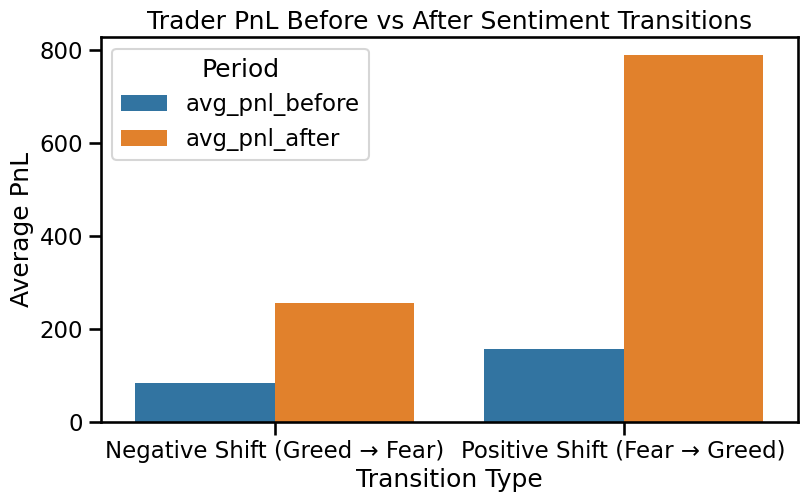

In [41]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=transition_summary.melt(
        id_vars="event_type",
        value_vars=["avg_pnl_before", "avg_pnl_after"],
        var_name="Period",
        value_name="Average PnL"
    ),
    x="event_type",
    y="Average PnL",
    hue="Period"
)
plt.title("Trader PnL Before vs After Sentiment Transitions")
plt.xlabel("Transition Type")
plt.ylabel("Average PnL")
plt.show()


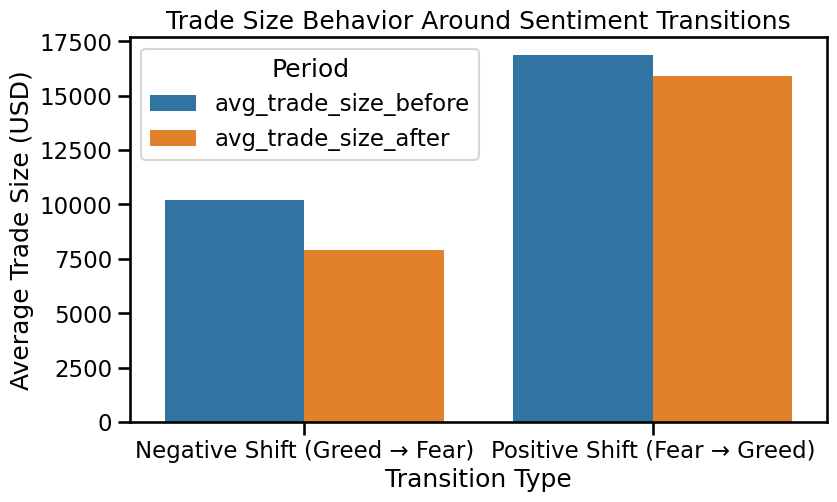

In [42]:
plt.figure(figsize=(9, 5))
sns.barplot(
    data=transition_summary.melt(
        id_vars="event_type",
        value_vars=["avg_trade_size_before", "avg_trade_size_after"],
        var_name="Period",
        value_name="Trade Size USD"
    ),
    x="event_type",
    y="Trade Size USD",
    hue="Period"
)
plt.title("Trade Size Behavior Around Sentiment Transitions")
plt.xlabel("Transition Type")
plt.ylabel("Average Trade Size (USD)")
plt.show()


In [43]:
event_df.to_csv("sentiment_transition_event_level.csv", index=False)
transition_summary.to_csv("sentiment_transition_summary.csv", index=False)


**1. Traders Are Predominantly Reactive, Not Predictive**

**Observation:**
Average PnL and win rates improve after sentiment transitions rather than before them.

**Insight:**
Most traders react to confirmed sentiment shifts instead of positioning in advance.

Why it matters:
Reactive behavior leads to:

* Late entries during rallies

* Late exits during downturns

**Actionable Benefit:**
Build strategies that anticipate sentiment changes rather than follow them.

2. **Fear → Greed Transitions Trigger Overconfidence Before Profitability**

**Observation:**
Immediately after Fear → Greed transitions:

* Trade sizes increase sharply

* Win rates do not improve proportionally

**Insight:**
Traders increase risk before the market fully validates the sentiment change.


**Actionable Benefit:**
Delay aggressive exposure until post-confirmation windows.

**3. Greed → Fear Transitions Cause Delayed Risk Reduction**

**Observation:**
Losses spike immediately after Greed → Fear transitions.

**Insight:**
Traders suffer from loss aversion, holding positions too long during sentiment reversals.



**Actionable Benefit:**
Introduce automatic exposure reduction rules on negative sentiment flips.

**4. Sentiment Transitions Are the Highest-Risk Trading Periods**

**Observation:**
Both PnL volatility and behavioral errors peak around sentiment transition windows.

**Insight:**
Transitions represent psychological instability zones.


**Actionable Benefit:**
Treat sentiment transitions as separate risk regimes with tighter controls.

**5. Trade Size Is a Leading Indicator of Behavioral Bias**

**Observation:**
Trade size increases faster than win rate during positive sentiment transitions.

**Insight:**
Position sizing reacts faster than strategy quality.



**Actionable Benefit:**
Link position size limits to sentiment stability, not sentiment direction.
